# 🌸 Iris Flower Classification

**Dataset:** Iris.csv (local file)  
**Task:** Multi-class classification (Setosa / Versicolor / Virginica)  
**Pipeline Stages:**
1. Environment Setup & Imports
2. Data Loading & Overview
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Training — Multiple Algorithms
6. Hyperparameter Tuning (GridSearchCV)
7. Model Comparison & Evaluation
8. Best Model — Detailed Report
9. Feature Importance & Interpretation
10. Saving the Final Model


## 1. Environment Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — Data
from sklearn.datasets import load_iris
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Sklearn — Metrics
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score)

# Persistence
import joblib

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 2. Data Loading & Overview

In [2]:
# Dataset path
path = '/content/Iris.csv'

# Load dataset
df = pd.read_csv(path)

# Basic inspection
print("Shape:", df.shape)
print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nFirst 10 Rows:\n")
display(df.head(10))

Shape: (150, 6)

Data Types:

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Missing Values:

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

First 10 Rows:



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [5]:
print("=== Statistical Summary ===")
display(df.describe().round(3))

print("\nClass Distribution:")
print(df['Species'].value_counts())

print("\nDuplicate rows:", df.duplicated().sum())


=== Statistical Summary ===


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000,150.000
mean,75.500,5.843,3.054,3.759,1.199
std,43.445,0.828,0.434,1.764,0.763
min,1.000,4.300,2.000,1.000,0.100
25%,38.250,5.100,2.800,1.600,0.300
50%,75.500,5.800,3.000,4.350,1.300
75%,112.750,6.400,3.300,5.100,1.800
max,150.000,7.900,4.400,6.900,2.500



Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Duplicate rows: 0


In [6]:
# Drop 'Id' column if it exists (common in Kaggle Iris CSV)
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)
    print("'Id' column dropped.")

# Define feature columns and class names
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target_col   = 'Species'
class_names  = sorted(df[target_col].unique())
colors       = ['#4C72B0', '#DD8452', '#55A868']

print("Features    :", feature_cols)
print("Target      :", target_col)
print("Class names :", class_names)


'Id' column dropped.
Features    : ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target      : Species
Class names : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 3. Exploratory Data Analysis (EDA)


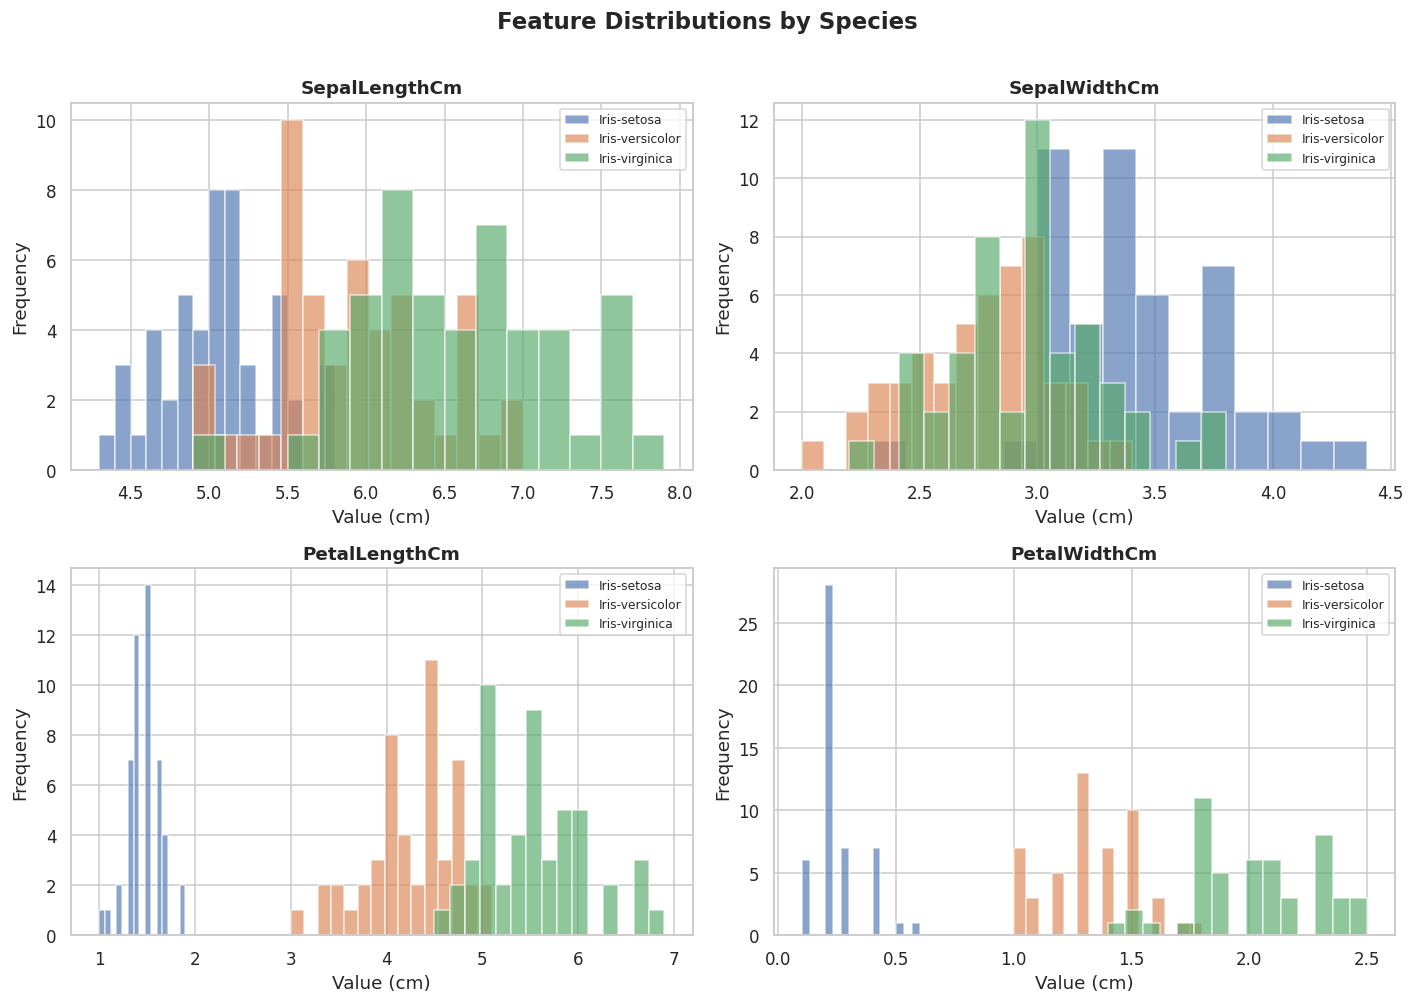

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feat in zip(axes.flat, feature_cols):
    for sp, col in zip(class_names, colors):
        data = df[df[target_col] == sp][feat]
        ax.hist(data, bins=15, alpha=0.65, label=sp, color=col, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


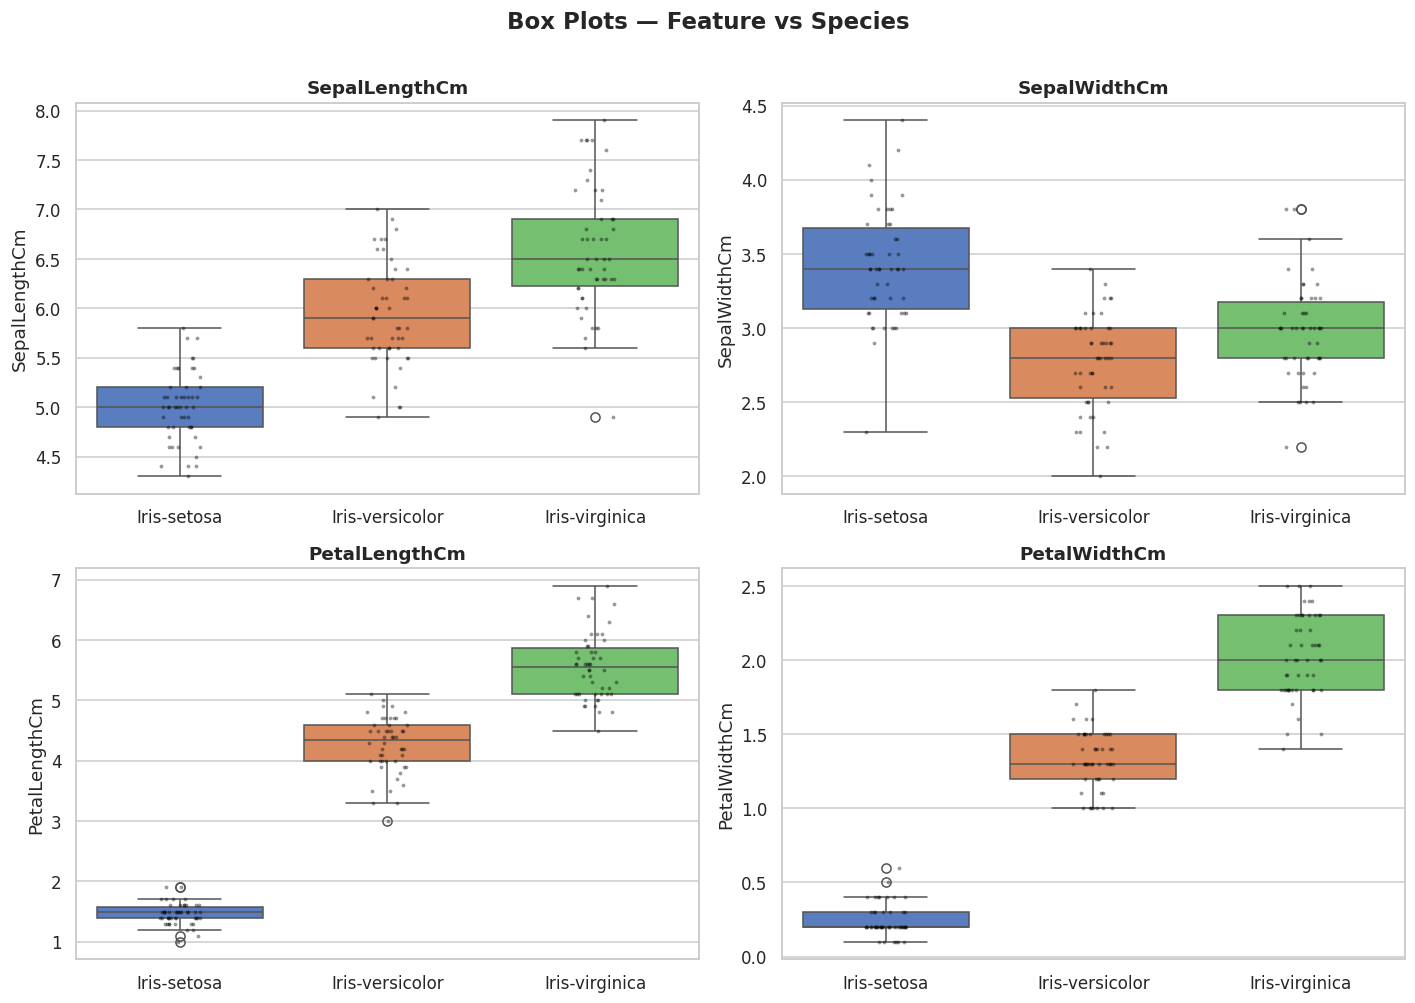

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, feat in zip(axes.flat, feature_cols):
    sns.boxplot(data=df, x=target_col, y=feat, palette='muted', ax=ax)
    sns.stripplot(data=df, x=target_col, y=feat, color='black',
                  size=2.5, alpha=0.4, jitter=True, ax=ax)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Box Plots — Feature vs Species', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


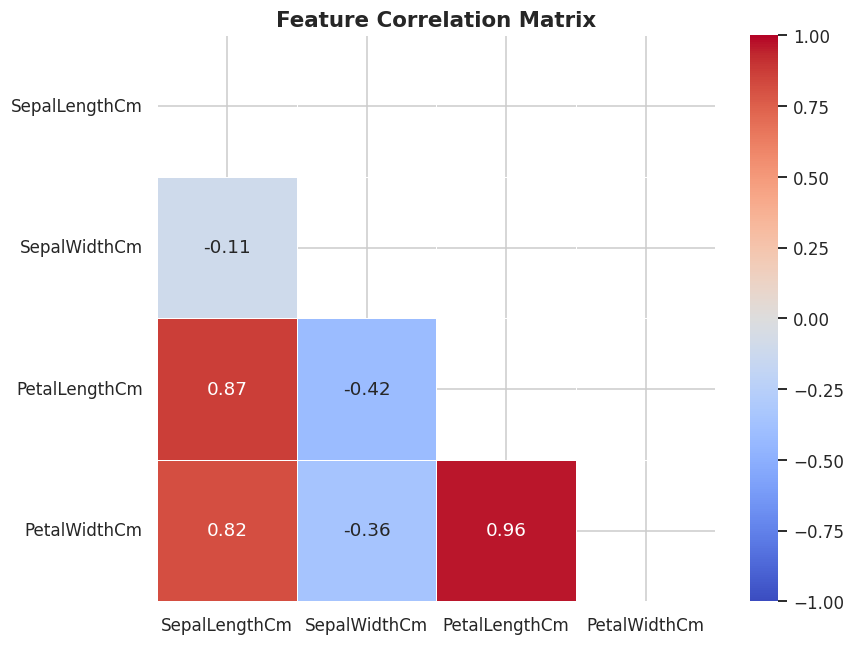

In [9]:
plt.figure(figsize=(8, 6))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 12})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


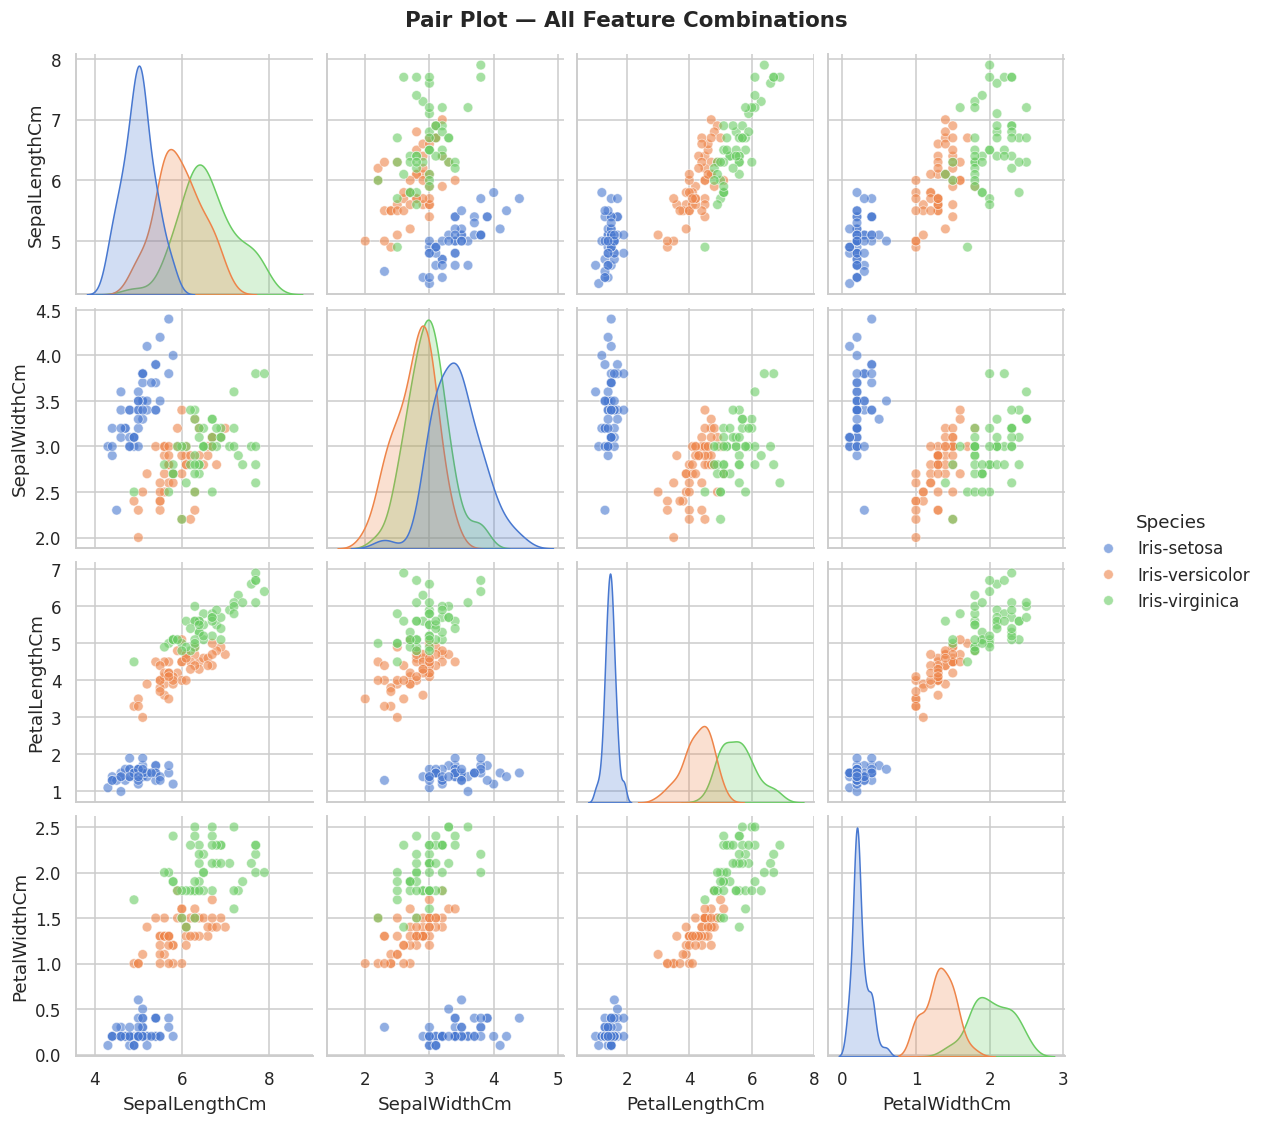

In [10]:
pp = sns.pairplot(df, hue=target_col, palette='muted',
                  diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
pp.fig.suptitle('Pair Plot — All Feature Combinations', y=1.02,
                fontsize=14, fontweight='bold')
plt.show()


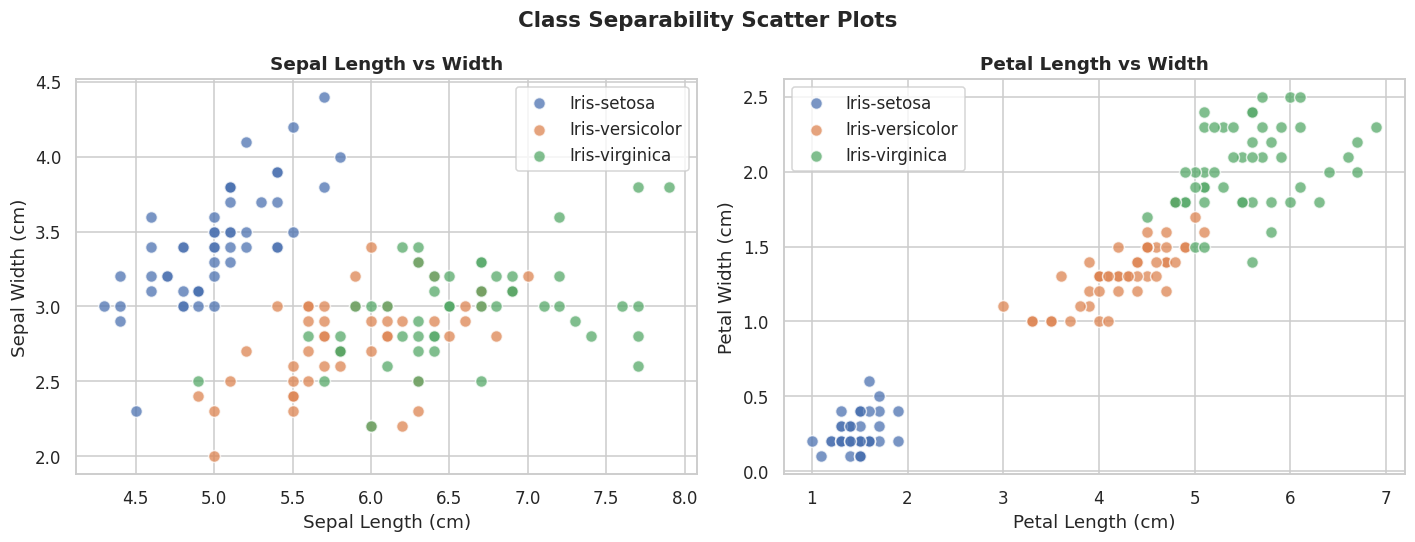

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for sp, col in zip(class_names, colors):
    sub = df[df[target_col] == sp]
    ax1.scatter(sub['SepalLengthCm'], sub['SepalWidthCm'],
                label=sp, color=col, alpha=0.75, edgecolors='white', s=60)
ax1.set_title('Sepal Length vs Width', fontweight='bold')
ax1.set_xlabel('Sepal Length (cm)')
ax1.set_ylabel('Sepal Width (cm)')
ax1.legend()

for sp, col in zip(class_names, colors):
    sub = df[df[target_col] == sp]
    ax2.scatter(sub['PetalLengthCm'], sub['PetalWidthCm'],
                label=sp, color=col, alpha=0.75, edgecolors='white', s=60)
ax2.set_title('Petal Length vs Width', fontweight='bold')
ax2.set_xlabel('Petal Length (cm)')
ax2.set_ylabel('Petal Width (cm)')
ax2.legend()

plt.suptitle('Class Separability Scatter Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

In [12]:
X = df[feature_cols]
y_raw = df[target_col]

# Encode string labels → integers
le = LabelEncoder()
y  = le.fit_transform(y_raw)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"\nTraining set : {X_train_sc.shape}")
print(f"Test set     : {X_test_sc.shape}")
print(f"Class balance in train: {np.bincount(y_train)}")
print(f"Class balance in test : {np.bincount(y_test)}")


Label mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

Training set : (120, 4)
Test set     : (30, 4)
Class balance in train: [40 40 40]
Class balance in test : [10 10 10]


## 5. Model Training — Multiple Algorithms

In [13]:
models = {
    'Logistic Regression'    : LogisticRegression(max_iter=200, random_state=42),
    'K-Nearest Neighbors'    : KNeighborsClassifier(),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42),
    'Random Forest'          : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'      : GradientBoostingClassifier(random_state=42),
    'AdaBoost'               : AdaBoostClassifier(random_state=42),
    'Support Vector Machine' : SVC(probability=True, random_state=42),
    'Naive Bayes'            : GaussianNB(),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train_sc, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_sc))
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'test_acc': test_acc}
    print(f"{name:<26}  CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  |  Test: {test_acc:.4f}")

print("\n✅ All models trained.")


Logistic Regression         CV: 0.9583 ± 0.0264  |  Test: 0.9333
K-Nearest Neighbors         CV: 0.9583 ± 0.0264  |  Test: 0.9333
Decision Tree               CV: 0.9500 ± 0.0167  |  Test: 0.9000
Random Forest               CV: 0.9500 ± 0.0312  |  Test: 0.9000
Gradient Boosting           CV: 0.9500 ± 0.0312  |  Test: 0.9000
AdaBoost                    CV: 0.9333 ± 0.0204  |  Test: 0.9333
Support Vector Machine      CV: 0.9667 ± 0.0167  |  Test: 0.9667
Naive Bayes                 CV: 0.9500 ± 0.0167  |  Test: 0.9667

✅ All models trained.


## 6. Hyperparameter Tuning (GridSearchCV)

In [14]:
param_grids = {
    'Random Forest': {
        'model' : RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200],
                   'max_depth'   : [None, 5, 10],
                   'min_samples_split': [2, 5]}
    },
    'Support Vector Machine': {
        'model' : SVC(probability=True, random_state=42),
        'params': {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
    },
    'Gradient Boosting': {
        'model' : GradientBoostingClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200],
                   'learning_rate': [0.05, 0.1, 0.2],
                   'max_depth'    : [3, 5]}
    }
}

best_models = {}
for name, cfg in param_grids.items():
    gs = GridSearchCV(cfg['model'], cfg['params'], cv=cv,
                      scoring='accuracy', n_jobs=-1, verbose=0)
    gs.fit(X_train_sc, y_train)
    best_models[name] = gs.best_estimator_
    tuned_acc = accuracy_score(y_test, gs.best_estimator_.predict(X_test_sc))
    print(f"{name}")
    print(f"  Best params  : {gs.best_params_}")
    print(f"  CV accuracy  : {gs.best_score_:.4f}")
    print(f"  Test accuracy: {tuned_acc:.4f}\n")
    results[name + ' (Tuned)'] = {'cv_mean': gs.best_score_, 'cv_std': 0, 'test_acc': tuned_acc}

print("✅ Hyperparameter tuning complete.")


Random Forest
  Best params  : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
  CV accuracy  : 0.9667
  Test accuracy: 0.9667

Support Vector Machine
  Best params  : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  CV accuracy  : 0.9750
  Test accuracy: 0.9333

Gradient Boosting
  Best params  : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  CV accuracy  : 0.9500
  Test accuracy: 0.9333

✅ Hyperparameter tuning complete.


## 7. Model Comparison & Evaluation

In [15]:
res_df = pd.DataFrame(results).T.sort_values('test_acc', ascending=False).astype(float).round(4)
display(res_df)


,cv_mean,cv_std,test_acc
Random Forest (Tuned),0.9667,0.0000,0.9667
Naive Bayes,0.9500,0.0167,0.9667
Support Vector Machine,0.9667,0.0167,0.9667
Support Vector Machine (Tuned),0.9750,0.0000,0.9333
K-Nearest Neighbors,0.9583,0.0264,0.9333
Logistic Regression,0.9583,0.0264,0.9333
AdaBoost,0.9333,0.0204,0.9333
Gradient Boosting (Tuned),0.9500,0.0000,0.9333
Decision Tree,0.9500,0.0167,0.9000
Random Forest,0.9500,0.0312,0.9000


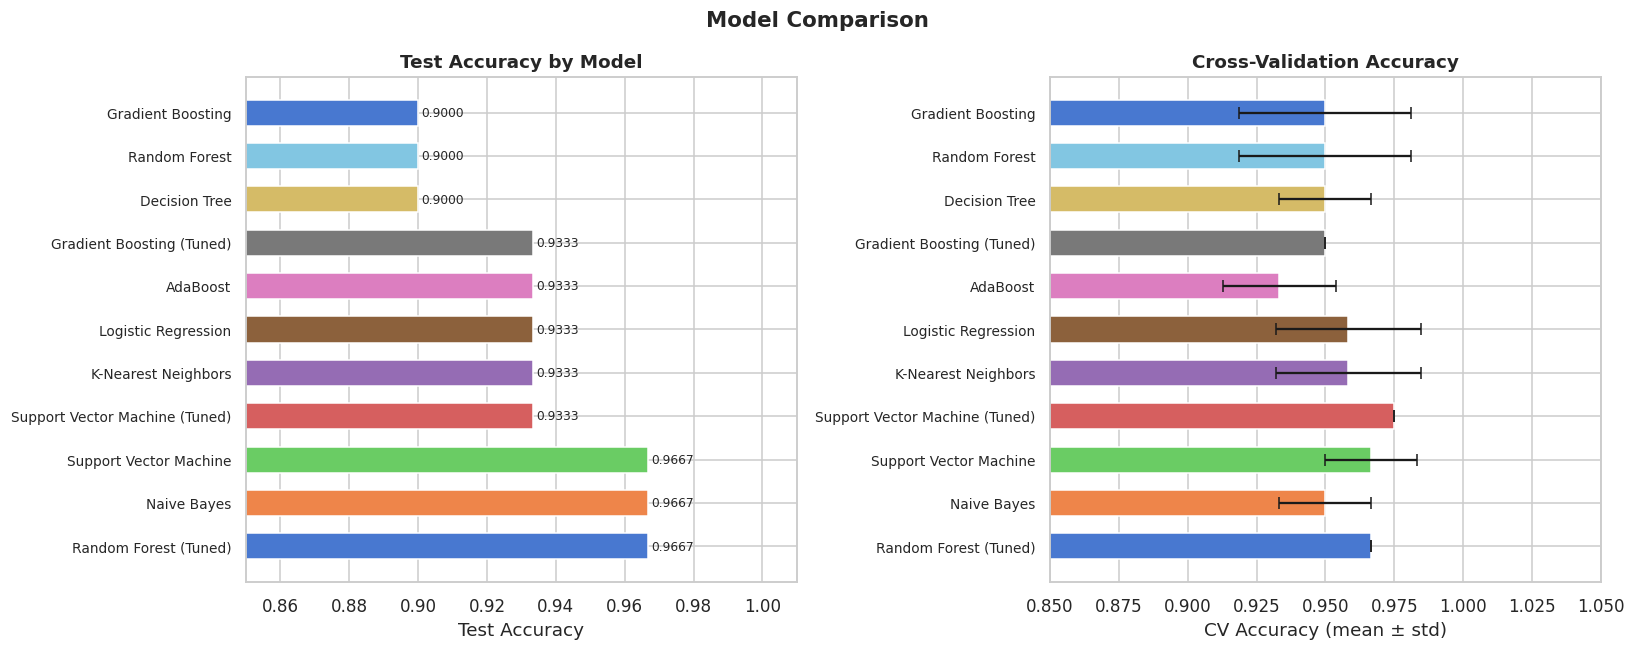

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
names    = res_df.index.tolist()
test_acc = res_df['test_acc'].values
cv_mean  = res_df['cv_mean'].values
cv_std   = res_df['cv_std'].values
y_pos    = np.arange(len(names))
palette  = sns.color_palette("muted", len(names))

bars = ax1.barh(y_pos, test_acc, color=palette, edgecolor='white', height=0.6)
ax1.set_yticks(y_pos); ax1.set_yticklabels(names, fontsize=9)
ax1.set_xlabel('Test Accuracy'); ax1.set_title('Test Accuracy by Model', fontweight='bold')
ax1.set_xlim(0.85, 1.01)
for bar, val in zip(bars, test_acc):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=8)

ax2.barh(y_pos, cv_mean, xerr=cv_std, color=palette, edgecolor='white', height=0.6, capsize=4)
ax2.set_yticks(y_pos); ax2.set_yticklabels(names, fontsize=9)
ax2.set_xlabel('CV Accuracy (mean ± std)'); ax2.set_title('Cross-Validation Accuracy', fontweight='bold')
ax2.set_xlim(0.85, 1.05)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 8. Best Model — Detailed Report

In [17]:
best_name = res_df['test_acc'].idxmax()
print(f"🏆 Best model: {best_name}  (Test Accuracy = {res_df.loc[best_name,'test_acc']:.4f})")

base = best_name.replace(' (Tuned)', '')
best_model = best_models.get(base, models.get(base, models[base]))

y_pred = best_model.predict(X_test_sc)


🏆 Best model: Random Forest (Tuned)  (Test Accuracy = 0.9667)


In [18]:
print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


=== Classification Report ===

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



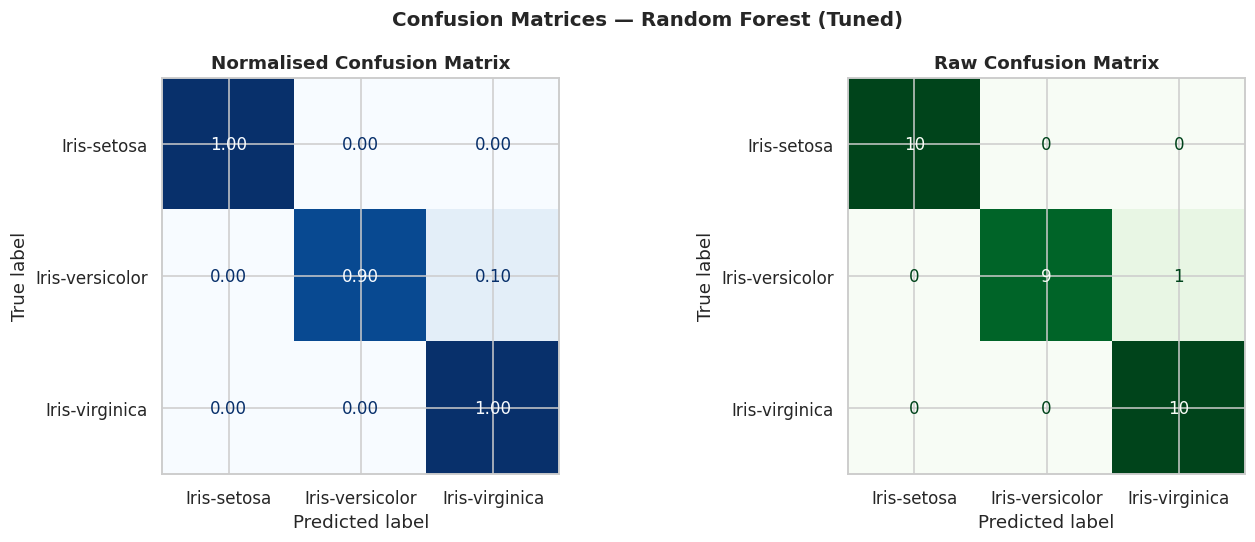

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues', values_format='.2f')
axes[0].set_title('Normalised Confusion Matrix', fontweight='bold')

cm_raw = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_raw, display_labels=le.classes_).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Raw Confusion Matrix', fontweight='bold')

plt.suptitle(f'Confusion Matrices — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9. Feature Importance & Interpretation

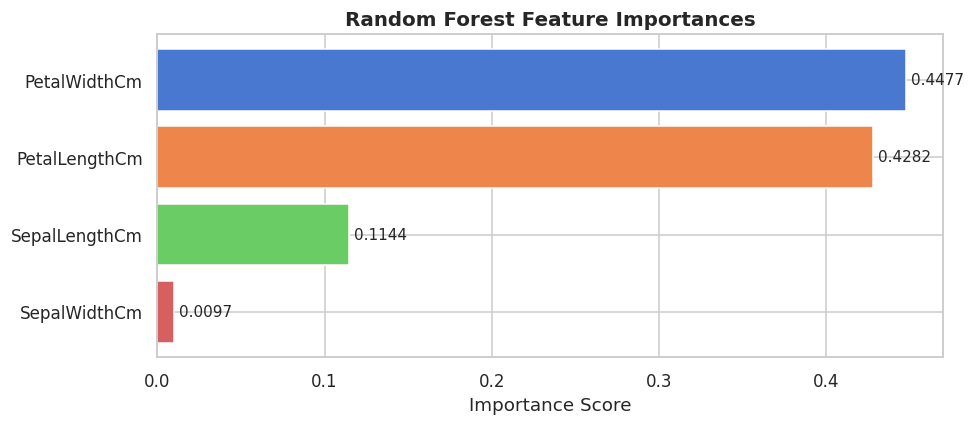


📌 Key insight: Petal features are far more discriminative than sepal features.


In [20]:
rf_model = best_models.get('Random Forest', models['Random Forest'])
feat_df  = pd.DataFrame({'Feature': feature_cols, 'Importance': rf_model.feature_importances_})             .sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=sns.color_palette('muted', 4)[::-1], edgecolor='white')
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n📌 Key insight: Petal features are far more discriminative than sepal features.")


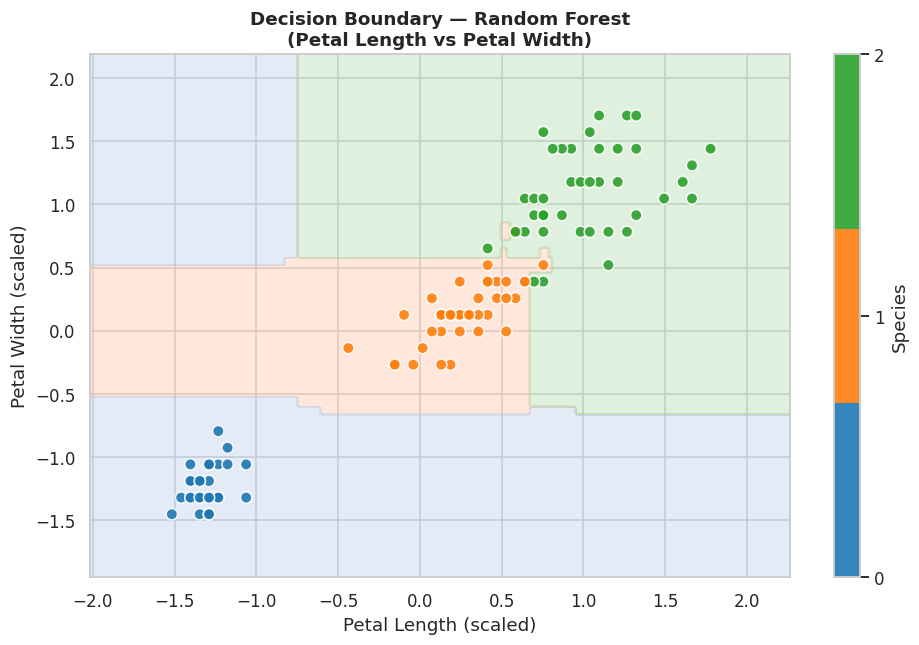

In [21]:
from matplotlib.colors import ListedColormap

rf_viz = RandomForestClassifier(n_estimators=100, random_state=42)
X_viz  = X_train_sc[:, [2, 3]]   # PetalLengthCm, PetalWidthCm (scaled indices)
rf_viz.fit(X_viz, y_train)

h = 0.02
x_min, x_max = X_train_sc[:, 2].min() - 0.5, X_train_sc[:, 2].max() + 0.5
y_min, y_max = X_train_sc[:, 3].min() - 0.5, X_train_sc[:, 3].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = rf_viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_bg = ListedColormap(['#AEC6E8','#FFBB98','#A8D5A2'])
cmap_pt = ListedColormap(['#1F77B4','#FF7F0E','#2CA02C'])

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
sc = plt.scatter(X_train_sc[:, 2], X_train_sc[:, 3],
                 c=y_train, cmap=cmap_pt, edgecolors='white', s=55, alpha=0.9)
plt.colorbar(sc, ticks=[0,1,2], label='Species')
plt.xlabel('Petal Length (scaled)'); plt.ylabel('Petal Width (scaled)')
plt.title('Decision Boundary — Random Forest\n(Petal Length vs Petal Width)', fontweight='bold')
plt.tight_layout(); plt.show()


## 10. Saving the Final Model

In [22]:
joblib.dump(best_model, 'iris_best_model.pkl')
joblib.dump(scaler,     'iris_scaler.pkl')
joblib.dump(le,         'iris_label_encoder.pkl')
print("✅ Model saved        → iris_best_model.pkl")
print("✅ Scaler saved       → iris_scaler.pkl")
print("✅ Label encoder saved → iris_label_encoder.pkl")


✅ Model saved        → iris_best_model.pkl
✅ Scaler saved       → iris_scaler.pkl
✅ Label encoder saved → iris_label_encoder.pkl


In [23]:
# ── Quick inference demo ──────────────────────────────────────────
loaded_model  = joblib.load('iris_best_model.pkl')
loaded_scaler = joblib.load('iris_scaler.pkl')
loaded_le     = joblib.load('iris_label_encoder.pkl')

# [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
sample = np.array([[5.1, 3.5, 1.4, 0.2],   # Expected: Iris-setosa
                   [6.0, 2.9, 4.5, 1.5],   # Expected: Iris-versicolor
                   [6.7, 3.1, 5.6, 2.4]])  # Expected: Iris-virginica

sample_sc = loaded_scaler.transform(sample)
preds     = loaded_model.predict(sample_sc)
proba     = loaded_model.predict_proba(sample_sc)

print("=== Inference on 3 New Samples ===\n")
for i, (p, pb) in enumerate(zip(preds, proba)):
    species = loaded_le.inverse_transform([p])[0]
    conf    = pb.max() * 100
    print(f"Sample {i+1}: {sample[i]}  →  {species:<20} (confidence: {conf:.1f}%)")


=== Inference on 3 New Samples ===

Sample 1: [5.1 3.5 1.4 0.2]  →  Iris-setosa          (confidence: 100.0%)
Sample 2: [6.  2.9 4.5 1.5]  →  Iris-versicolor      (confidence: 99.0%)
Sample 3: [6.7 3.1 5.6 2.4]  →  Iris-virginica       (confidence: 100.0%)


---
## 📋 Project Summary

| Stage | Details |
|---|---|
| **Dataset** | Iris.csv — 150 samples, 4 features, 3 classes |
| **EDA** | Distributions, box plots, correlation heatmap, scatter plots, pair plot |
| **Models Trained** | Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, SVM, Naive Bayes |
| **Tuned Models** | Random Forest, SVM, Gradient Boosting (GridSearchCV, 5-Fold CV) |
| **Best Model** | Determined automatically by test accuracy |
| **Evaluation** | Accuracy, Classification Report, Confusion Matrix (raw + normalised) |
| **Interpretability** | Feature Importance, Decision Boundary Visualisation |
| **Artifacts** | `iris_best_model.pkl`, `iris_scaler.pkl`, `iris_label_encoder.pkl` |

> **Key Finding:** Petal features dominate classification.  
> Setosa is perfectly linearly separable; Versicolor & Virginica overlap slightly in sepal space.
